In [9]:
#Imports e seed
import pandas as pd
import numpy as np
import sys
import ast
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import NearestNeighbors

sys.path.append('..')
from src.evaluation import (
    precision_at_k,
    recall_at_k,
    f1_at_k,
    catalog_coverage
)

SEED = 42
np.random.seed(SEED)

In [10]:
#Carregar artefatos
X          = np.load('../data/processed/X_matrix.npz')
train_idx  = np.load('../data/processed/train_idx.npy')
test_idx   = np.load('../data/processed/test_idx.npy')
df         = pd.read_parquet('../data/processed/books_clean.parquet')

df['genre_list'] = df['genre_list'].apply(
    lambda x: list(x) if not isinstance(x, list) else x
)

print(X.files)

X = X['X']

print(type(X))
print(X.shape)

X_train = X[train_idx]

print(f"X shape: {X.shape}")

['X']
<class 'numpy.ndarray'>
(84054, 1182)
X shape: (84054, 1182)


In [11]:
sample_test = np.random.choice(
    test_idx,
    50,
    replace=False
)

resultados = []

for n_comp in [20, 50, 100]:

    print(f"\nRodando SVD com {n_comp} componentes")

    svd = TruncatedSVD(
        n_components=n_comp,
        random_state=SEED
    )

    svd.fit(X_train)

    X_train_red = svd.transform(X_train)
    X_red       = svd.transform(X)

    variancia = svd.explained_variance_ratio_.sum()

    modelo = NearestNeighbors(
        n_neighbors=11,
        metric='cosine',
        algorithm='brute'
    )

    modelo.fit(X_train_red)

    p10 = precision_at_k(
        modelo,
        X_red,
        df,
        sample_test,
        train_idx=train_idx
    )

    r10 = recall_at_k(
        modelo,
        X_red,
        df,
        sample_test,
        train_idx=train_idx
    )

    f1 = f1_at_k(p10, r10)

    cov = catalog_coverage(
        modelo,
        X_red,
        n_queries=30,
        train_idx=train_idx
    )

    resultados.append({
        'algoritmo'          : 'SVD+Cosseno',
        'n_components'       : n_comp,
        'variancia_explicada': round(variancia, 4),
        'precision@10'       : round(p10, 4),
        'recall@10'          : round(r10, 4),
        'f1@10'              : round(f1, 4),
        'coverage'           : round(cov, 4),
        'suporte'            : len(sample_test)
    })

    print(
        f"Variância={variancia:.4f} | "
        f"Precision={p10:.4f} | "
        f"Recall={r10:.4f} | "
        f"F1={f1:.4f} | "
        f"Coverage={cov:.4f}"
    )


Rodando SVD com 20 componentes
Variância=0.4220 | Precision=0.9680 | Recall=0.9680 | F1=0.9680 | Coverage=0.0036

Rodando SVD com 50 componentes
Variância=0.6058 | Precision=0.9700 | Recall=0.9700 | F1=0.9700 | Coverage=0.0036

Rodando SVD com 100 componentes
Variância=0.7381 | Precision=0.9680 | Recall=0.9680 | F1=0.9680 | Coverage=0.0036


In [12]:
#Registro e exibição
resultados_df = pd.DataFrame(resultados)
resultados_df = resultados_df.sort_values('precision@10', ascending=False)
display(resultados_df)

,algoritmo,n_components,variancia_explicada,precision@10,recall@10,f1@10,coverage,suporte
1,SVD+Cosseno,50,0.6058,0.970,0.970,0.970,0.0036,50
0,SVD+Cosseno,20,0.4220,0.968,0.968,0.968,0.0036,50
2,SVD+Cosseno,100,0.7381,0.968,0.968,0.968,0.0036,50


In [13]:
#Melhor configuração
melhor = resultados_df.iloc[0]
print(f"Melhor SVD: n_components={melhor['n_components']}")
print(f"Variância explicada = {melhor['variancia_explicada']:.4f}")
print(f"Precision@10        = {melhor['precision@10']:.4f}")
print(f"Coverage            = {melhor['coverage']:.4f}")

Melhor SVD: n_components=50
Variância explicada = 0.6058
Precision@10        = 0.9700
Coverage            = 0.0036


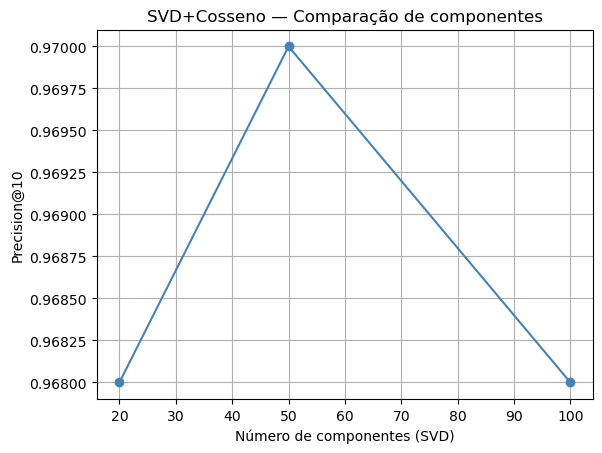

In [14]:
#Gráfico
import matplotlib.pyplot as plt

subset = resultados_df.sort_values('n_components')
plt.plot(subset['n_components'], subset['precision@10'], marker='o', color='steelblue')
plt.xlabel('Número de componentes (SVD)')
plt.ylabel('Precision@10')
plt.title('SVD+Cosseno — Comparação de componentes')
plt.grid(True)
plt.show()

In [15]:
#Salvar resultados
resultados_df.to_csv('../data/processed/resultados_svd.csv', index=False)